# Gradient Boosting To The Moon
Train/evaluate GBM for every attraction, then save final full-data models.


In [ ]:
from pathlib import Path
import re
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.ensemble import GradientBoostingRegressor

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from modeling.wait_time_forecasting.paths import notebook_context
from modeling.wait_time_forecasting.data_preparation import prepare_train_df
from modeling.wait_time_forecasting.gradient_boosting_waiting_time import gbm_train, gbm_predict

ctx = notebook_context(project_root=PROJECT_ROOT, create_models_dir=True)
PROJECT_ROOT = ctx["project_root"]
DATA_DIR = ctx["data_dir"]
MODELS_DIR = ctx["models_dir"]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("MODELS_DIR:", MODELS_DIR)

PROJECT_ROOT: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code
DATA_DIR: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\modeling\data\raw
MODELS_DIR: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\modeling\artifacts\models


In [ ]:
pack = prepare_train_df(data_dir=DATA_DIR, train_ratio=0.8)
full_df = pack['full_df'].copy()
train_df = pack['train_df'].copy()
test_df = pack['test_df'].copy()

attractions = sorted(train_df['ENTITY_DESCRIPTION_SHORT'].astype(str).str.strip().unique())

print('full rows:', len(full_df))
print('train rows:', len(train_df))
print('test rows:', len(test_df))
print('split timestamp:', pack['split_timestamp'])
print('num attractions:', len(attractions))
attractions[:10]

full rows: 294136
train rows: 238769
test rows: 55367
split timestamp: 2021-12-12 20:00:00
num attractions: 25


['Bumper Cars',
 'Bungee Jump',
 'Circus Train',
 'Crazy Dance',
 'Dizzy Dropper',
 'Drop Tower',
 'Flying Coaster',
 'Free Fall',
 'Giant Wheel',
 'Giga Coaster']

In [4]:
def sanitize_name(name: str) -> str:
    clean = re.sub(r'[^A-Za-z0-9]+', '_', str(name).strip())
    clean = clean.strip('_').lower()
    return clean or 'unknown_attraction'


def build_feature_matrix(df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    X = df.reindex(columns=feature_cols).copy()
    for c in feature_cols:
        X[c] = pd.to_numeric(X[c], errors='coerce')
        med = X[c].median(skipna=True)
        X[c] = X[c].fillna(float(med) if pd.notna(med) else 0.0)
    return X

  0%|          | 0/25 [00:00<?, ?it/s]


Attraction: Bumper Cars
GBM CV [Bumper Cars]: [########################] 100% (48/48)
best params: {'n_estimators': 450, 'learning_rate': 0.03, 'max_depth': 4, 'subsample': 0.8, 'min_samples_leaf': 2}
validation MAE (CV mean): 3.6190220295810045
7-day rows: 85
7-day valid eval rows: 85
7-day MAE: 3.6783979122055244
7-day RMSE: 4.955853204991702


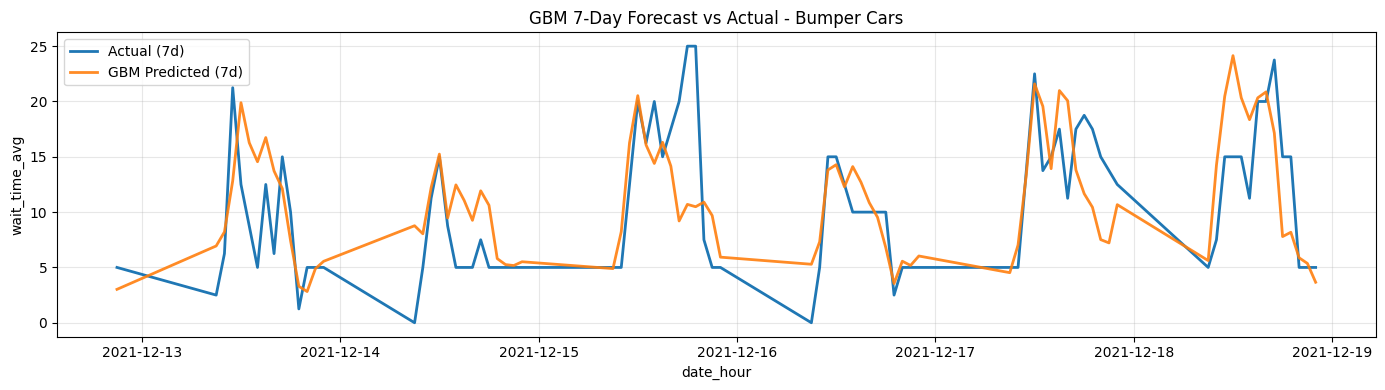

saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\src\models\bumper_cars_gradient_boosting.joblib

Attraction: Bungee Jump
GBM CV [Bungee Jump]: [########################] 100% (48/48)
best params: {'n_estimators': 450, 'learning_rate': 0.03, 'max_depth': 4, 'subsample': 0.8, 'min_samples_leaf': 2}
validation MAE (CV mean): 7.407812471409831
7-day rows: 80
7-day valid eval rows: 80
7-day MAE: 5.546622899756521
7-day RMSE: 6.7358044006432385


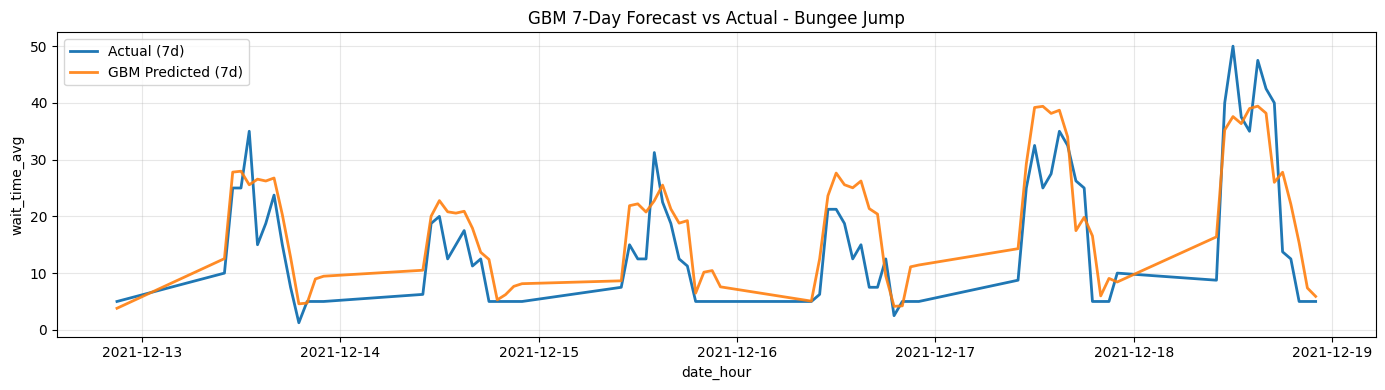

saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\src\models\bungee_jump_gradient_boosting.joblib

Attraction: Circus Train
GBM CV [Circus Train]: [########################] 100% (48/48)
best params: {'n_estimators': 150, 'learning_rate': 0.03, 'max_depth': 2, 'subsample': 1.0, 'min_samples_leaf': 1}
validation MAE (CV mean): 0.7647966868792409
7-day rows: 62
7-day valid eval rows: 62
7-day MAE: 0.38103618946249423
7-day RMSE: 0.8421455530916162


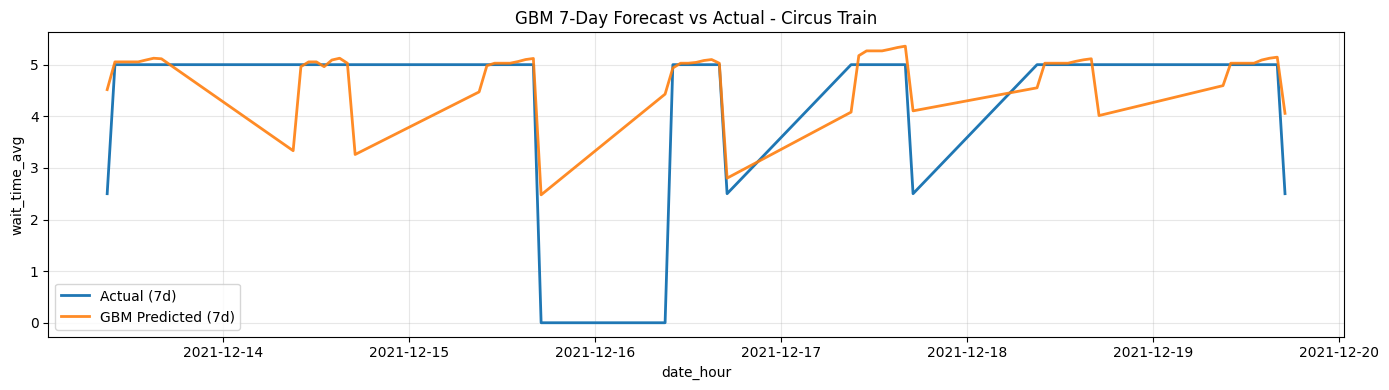

saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\src\models\circus_train_gradient_boosting.joblib

Attraction: Crazy Dance
GBM CV [Crazy Dance]: [########################] 100% (48/48)
best params: {'n_estimators': 150, 'learning_rate': 0.03, 'max_depth': 2, 'subsample': 1.0, 'min_samples_leaf': 1}
validation MAE (CV mean): 0.5004821257545946
7-day rows: 79
7-day valid eval rows: 79
7-day MAE: 0.27720269723483787
7-day RMSE: 0.7297254633165308


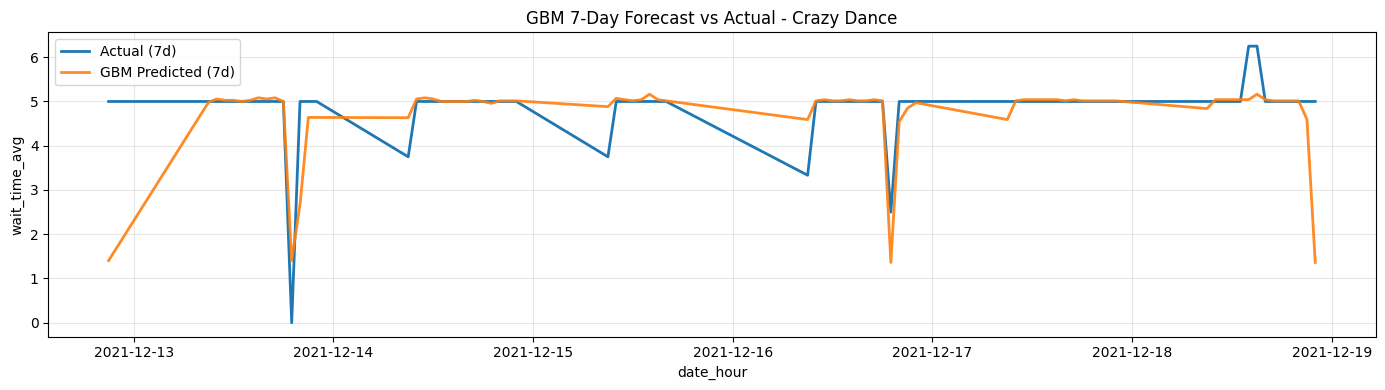

saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\src\models\crazy_dance_gradient_boosting.joblib

Attraction: Dizzy Dropper
GBM CV [Dizzy Dropper]: [########################] 100% (48/48)
best params: {'n_estimators': 450, 'learning_rate': 0.03, 'max_depth': 4, 'subsample': 0.8, 'min_samples_leaf': 2}
validation MAE (CV mean): 4.202748505276093
7-day rows: 85
7-day valid eval rows: 85
7-day MAE: 4.324278361960529
7-day RMSE: 5.831799377598537


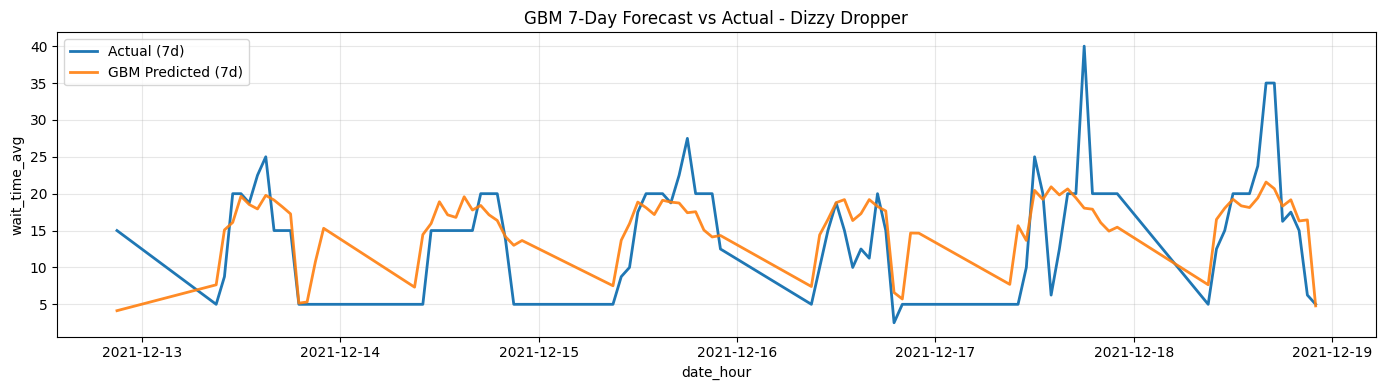

saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\src\models\dizzy_dropper_gradient_boosting.joblib

Attraction: Drop Tower
GBM CV [Drop Tower]: [########################] 100% (48/48)
best params: {'n_estimators': 350, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.9, 'min_samples_leaf': 2}
validation MAE (CV mean): 7.683155117735065
7-day rows: 85
7-day valid eval rows: 85
7-day MAE: 7.9836996913274945
7-day RMSE: 9.826247243308526


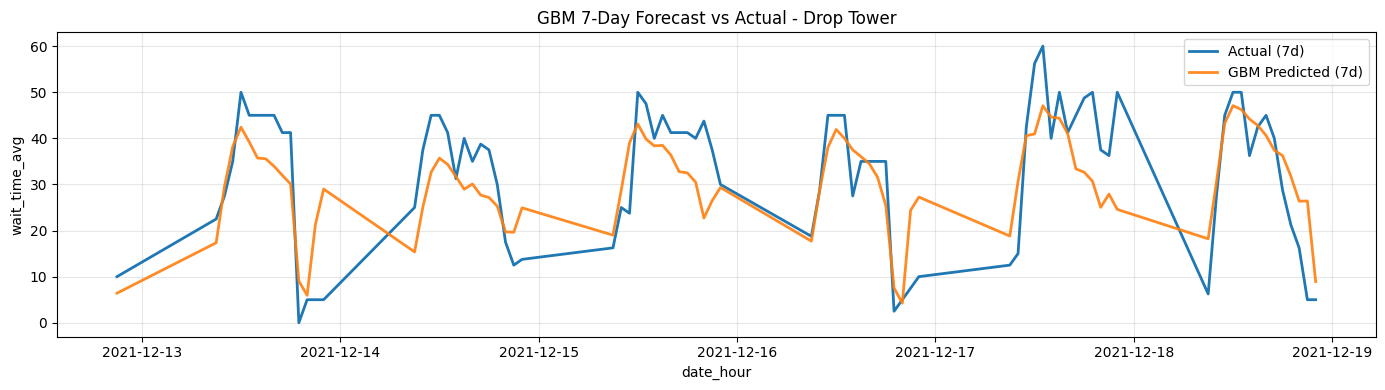

saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\src\models\drop_tower_gradient_boosting.joblib

Attraction: Flying Coaster
GBM CV [Flying Coaster]: [########################] 100% (48/48)
best params: {'n_estimators': 450, 'learning_rate': 0.03, 'max_depth': 4, 'subsample': 0.8, 'min_samples_leaf': 2}
validation MAE (CV mean): 7.465963555825928
7-day rows: 83
7-day valid eval rows: 83
7-day MAE: 5.316486442841965
7-day RMSE: 6.607842175325571


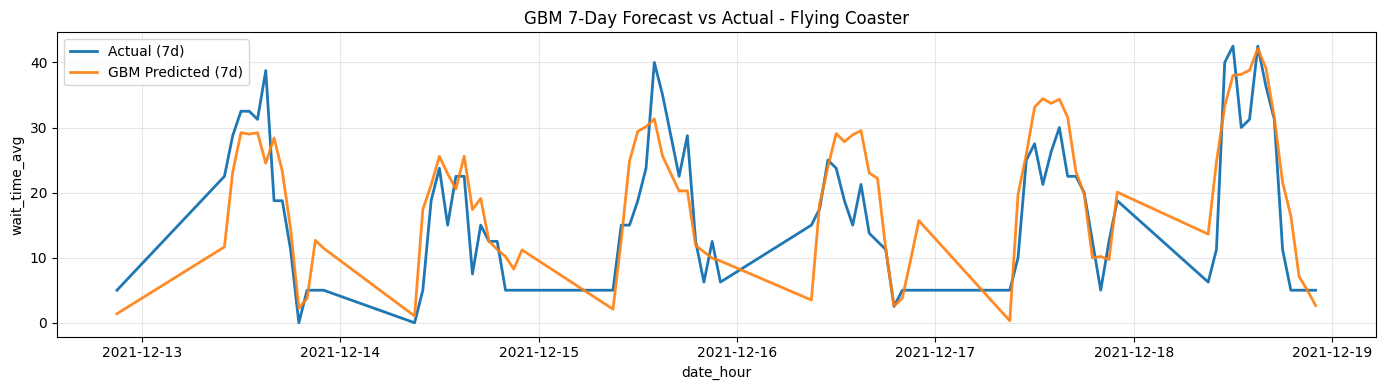

saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\src\models\flying_coaster_gradient_boosting.joblib

Attraction: Free Fall
GBM CV [Free Fall]: [########################] 100% (48/48)
best params: {'n_estimators': 350, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.9, 'min_samples_leaf': 2}
validation MAE (CV mean): 11.164945034200851
7-day rows: 71
7-day valid eval rows: 71
7-day MAE: 8.971823579852092
7-day RMSE: 10.65562016486868


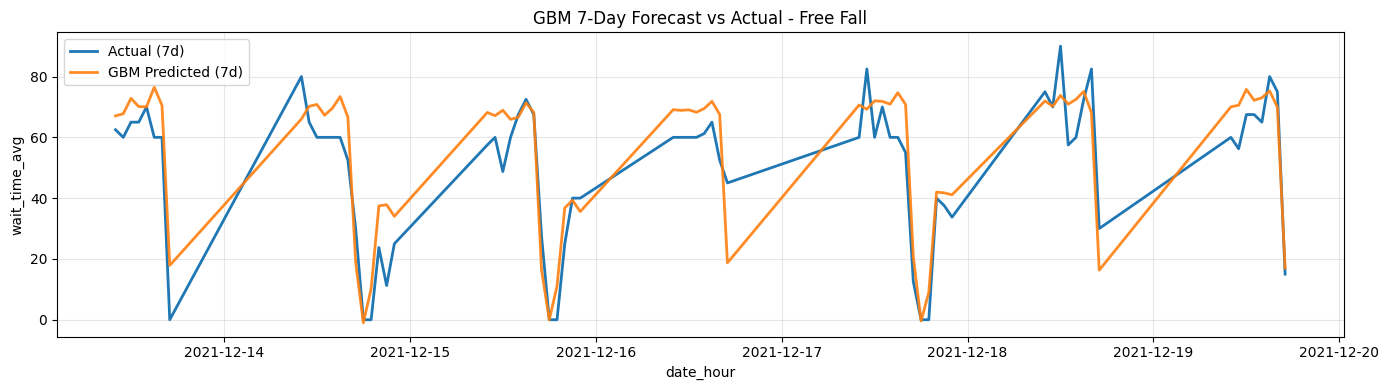

saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\src\models\free_fall_gradient_boosting.joblib

Attraction: Giant Wheel
GBM CV [Giant Wheel]: [########################] 100% (48/48)
best params: {'n_estimators': 350, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.9, 'min_samples_leaf': 2}
validation MAE (CV mean): 11.335650566973271
7-day rows: 84
7-day valid eval rows: 84
7-day MAE: 7.084153149729668
7-day RMSE: 9.623667681832536


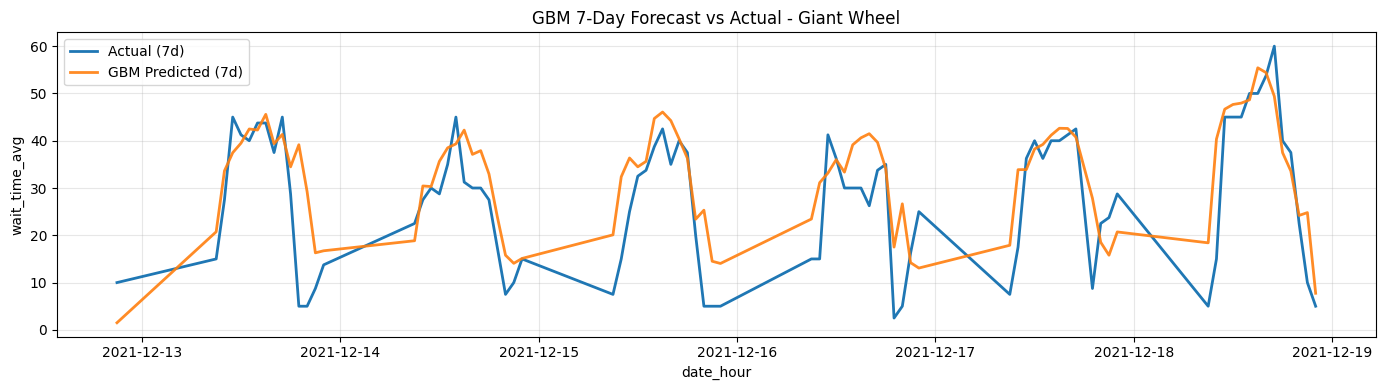

saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\src\models\giant_wheel_gradient_boosting.joblib

Attraction: Giga Coaster
GBM CV [Giga Coaster]: [########################] 100% (48/48)
best params: {'n_estimators': 450, 'learning_rate': 0.03, 'max_depth': 4, 'subsample': 0.8, 'min_samples_leaf': 2}
validation MAE (CV mean): 5.564538849931036
No test rows for this attraction. Skipping metrics/plot/final save.

Attraction: Go-Karts
GBM CV [Go-Karts]: [########################] 100% (48/48)
best params: {'n_estimators': 450, 'learning_rate': 0.03, 'max_depth': 4, 'subsample': 0.8, 'min_samples_leaf': 2}
validation MAE (CV mean): 9.614094563988651
7-day rows: 84
7-day valid eval rows: 84
7-day MAE: 8.327216593500818
7-day RMSE: 10.98094856720589


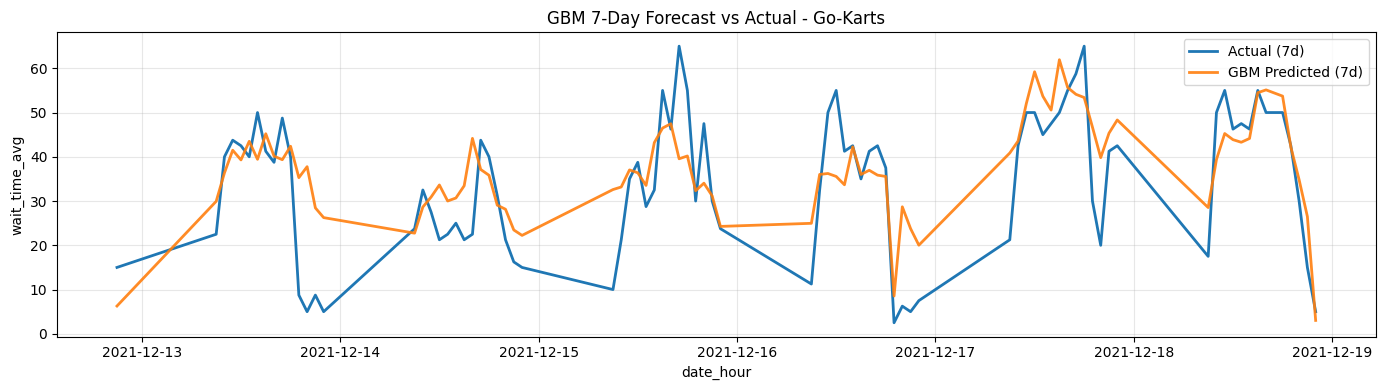

saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\src\models\go_karts_gradient_boosting.joblib

Attraction: Haunted House
GBM CV [Haunted House]: [########################] 100% (48/48)
best params: {'n_estimators': 450, 'learning_rate': 0.03, 'max_depth': 4, 'subsample': 0.8, 'min_samples_leaf': 2}
validation MAE (CV mean): 5.184746446266736
7-day rows: 83
7-day valid eval rows: 83
7-day MAE: 4.532254190747247
7-day RMSE: 5.786327052637688


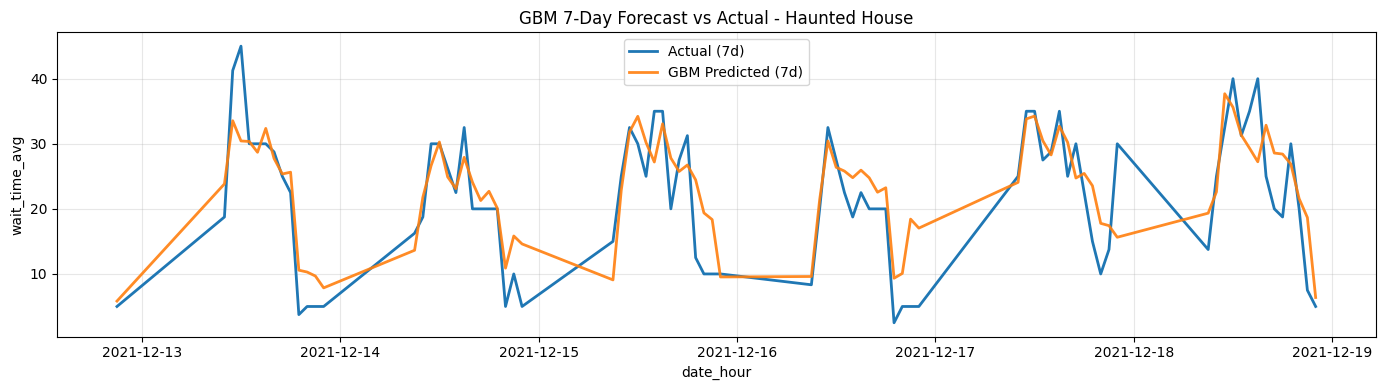

saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\src\models\haunted_house_gradient_boosting.joblib

Attraction: Himalaya Ride
GBM CV [Himalaya Ride]: [########################] 100% (48/48)
best params: {'n_estimators': 150, 'learning_rate': 0.03, 'max_depth': 2, 'subsample': 1.0, 'min_samples_leaf': 1}
validation MAE (CV mean): 0.4938530872476498
No test rows for this attraction. Skipping metrics/plot/final save.

Attraction: Inverted Coaster
GBM CV [Inverted Coaster]: [########################] 100% (48/48)
best params: {'n_estimators': 400, 'learning_rate': 0.03, 'max_depth': 3, 'subsample': 0.8, 'min_samples_leaf': 1}
validation MAE (CV mean): 14.012864077565998
7-day rows: 58
7-day valid eval rows: 58
7-day MAE: 4.447608996741375
7-day RMSE: 5.495464736361734


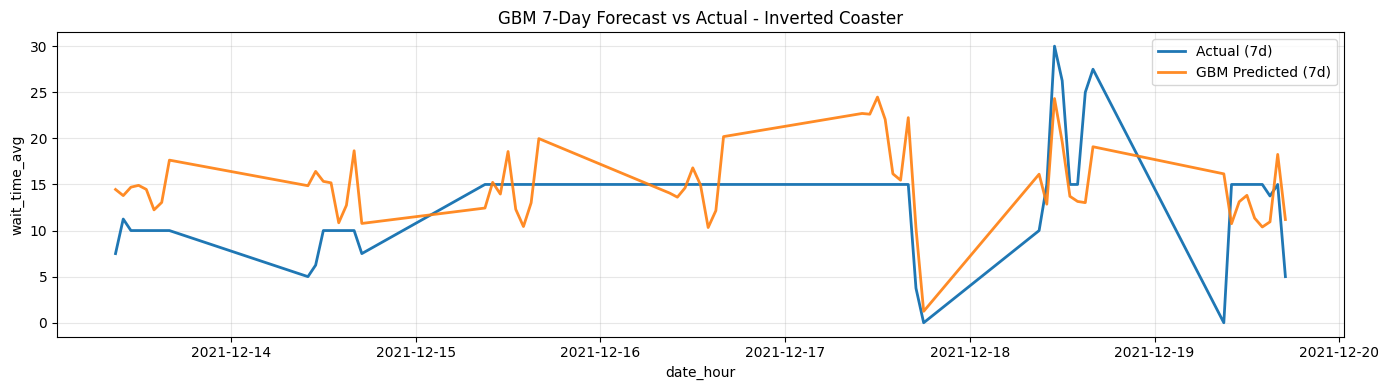

saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\src\models\inverted_coaster_gradient_boosting.joblib

Attraction: Kiddie Coaster
GBM CV [Kiddie Coaster]: [########################] 100% (48/48)
best params: {'n_estimators': 200, 'learning_rate': 0.03, 'max_depth': 3, 'subsample': 1.0, 'min_samples_leaf': 1}
validation MAE (CV mean): 2.283396632999465
7-day rows: 62
7-day valid eval rows: 62
7-day MAE: 1.3836488447136204
7-day RMSE: 1.8603239099373


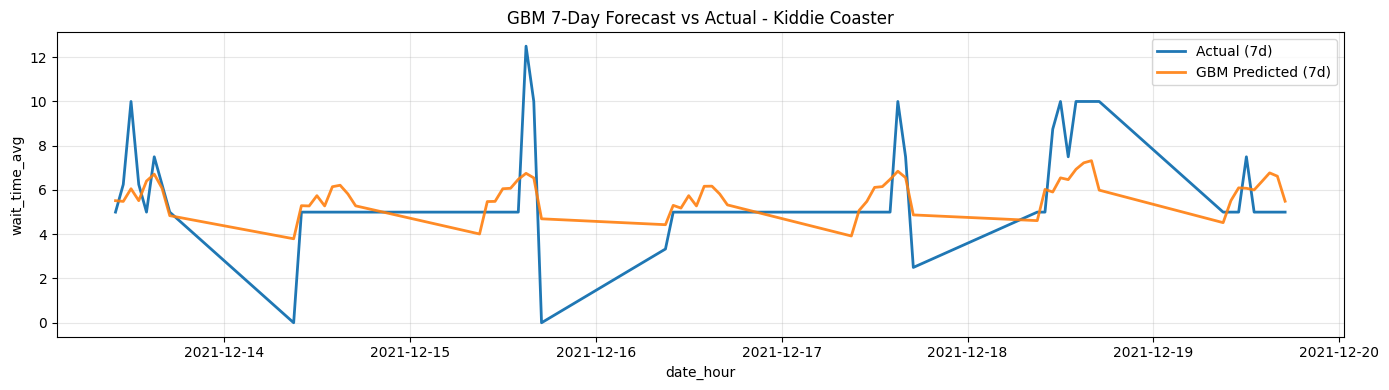

saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\src\models\kiddie_coaster_gradient_boosting.joblib

Attraction: Merry Go Round
GBM CV [Merry Go Round]: [########################] 100% (48/48)
best params: {'n_estimators': 450, 'learning_rate': 0.03, 'max_depth': 4, 'subsample': 0.8, 'min_samples_leaf': 2}
validation MAE (CV mean): 7.84696571513143
7-day rows: 81
7-day valid eval rows: 81
7-day MAE: 5.87752875063549
7-day RMSE: 7.481592433751195


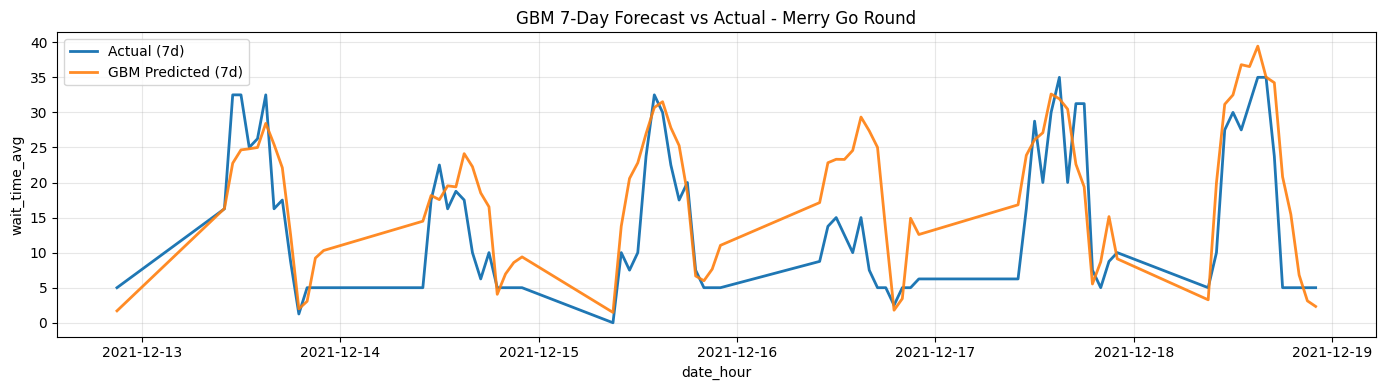

saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\src\models\merry_go_round_gradient_boosting.joblib

Attraction: Oz Theatre
GBM CV [Oz Theatre]: [########################] 100% (48/48)
best params: {'n_estimators': 150, 'learning_rate': 0.03, 'max_depth': 2, 'subsample': 1.0, 'min_samples_leaf': 1}
validation MAE (CV mean): 3.7921802190646794
7-day rows: 58
7-day valid eval rows: 58
7-day MAE: 3.2132739295912147
7-day RMSE: 4.062237701865631


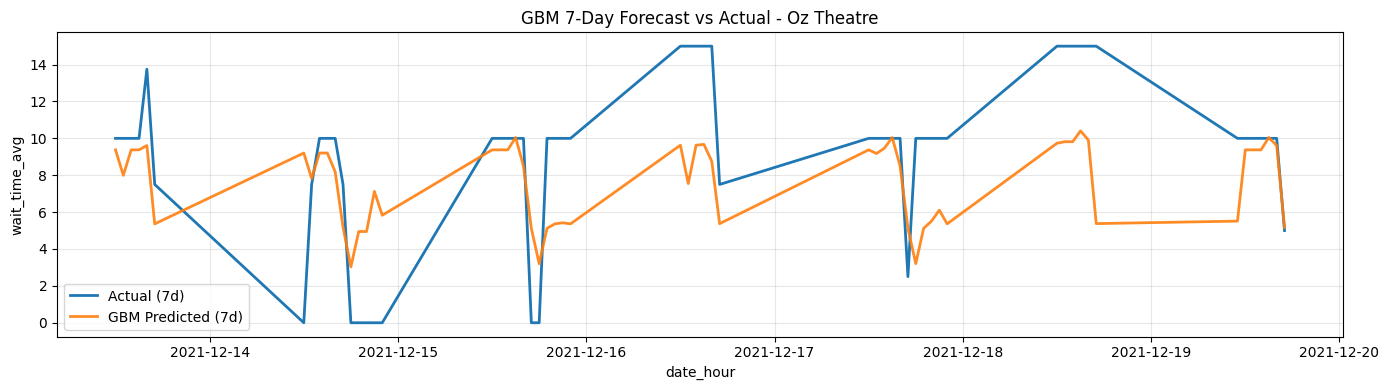

saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\src\models\oz_theatre_gradient_boosting.joblib

Attraction: Rapids Ride
GBM CV [Rapids Ride]: [########################] 100% (48/48)
best params: {'n_estimators': 350, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.9, 'min_samples_leaf': 2}
validation MAE (CV mean): 6.829349120664594
7-day rows: 62
7-day valid eval rows: 62
7-day MAE: 7.154013531625049
7-day RMSE: 8.558550998960298


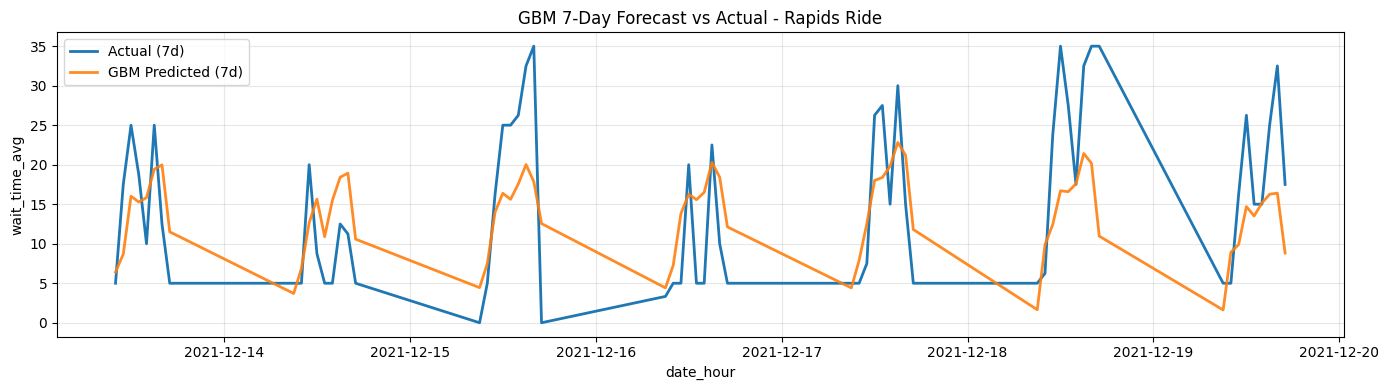

saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\src\models\rapids_ride_gradient_boosting.joblib

Attraction: Roller Coaster
GBM CV [Roller Coaster]: [########################] 100% (48/48)
best params: {'n_estimators': 300, 'learning_rate': 0.03, 'max_depth': 3, 'subsample': 0.9, 'min_samples_leaf': 1}
validation MAE (CV mean): 5.769958553577163
7-day rows: 82
7-day valid eval rows: 82
7-day MAE: 5.138716482559358
7-day RMSE: 6.329381635136773


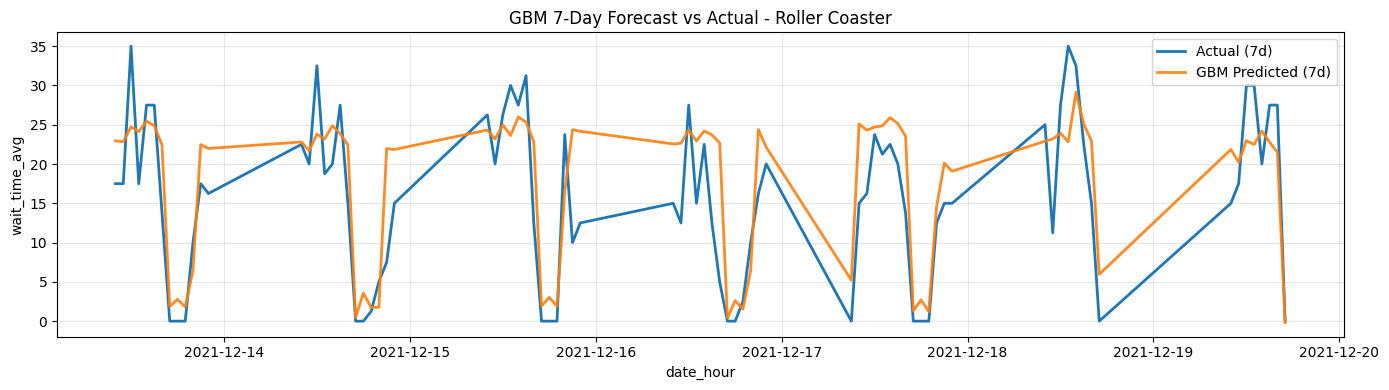

saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\src\models\roller_coaster_gradient_boosting.joblib

Attraction: Spinning Coaster
GBM CV [Spinning Coaster]: [########################] 100% (48/48)
best params: {'n_estimators': 450, 'learning_rate': 0.03, 'max_depth': 4, 'subsample': 0.8, 'min_samples_leaf': 2}
validation MAE (CV mean): 9.093178553089563
7-day rows: 84
7-day valid eval rows: 84
7-day MAE: 7.533985004342978
7-day RMSE: 9.350329073349245


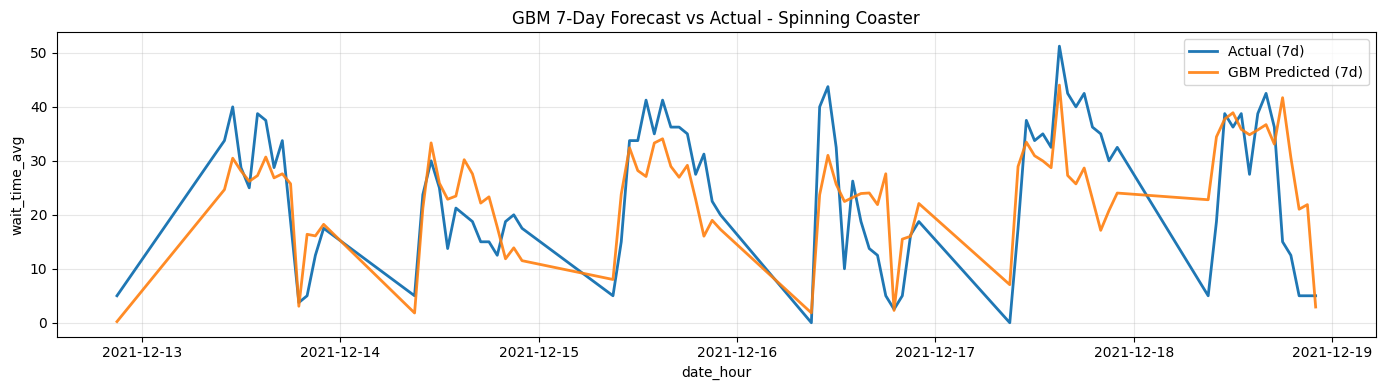

saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\src\models\spinning_coaster_gradient_boosting.joblib

Attraction: Spiral Slide
GBM CV [Spiral Slide]: [########################] 100% (48/48)
best params: {'n_estimators': 450, 'learning_rate': 0.03, 'max_depth': 4, 'subsample': 0.8, 'min_samples_leaf': 2}
validation MAE (CV mean): 17.42958772307888
7-day rows: 66
7-day valid eval rows: 66
7-day MAE: 8.044890152215357
7-day RMSE: 9.33367075086439


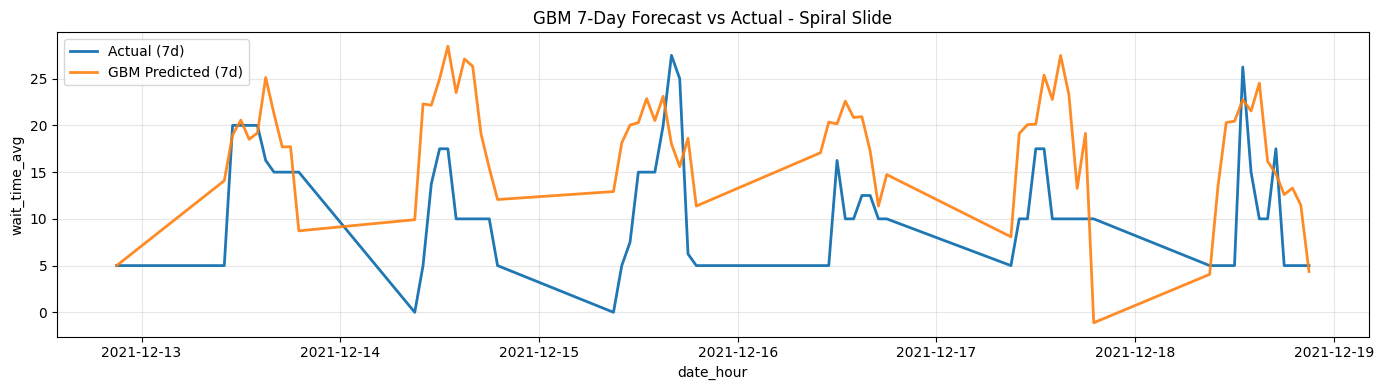

saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\src\models\spiral_slide_gradient_boosting.joblib

Attraction: Superman Ride
GBM CV [Superman Ride]: [########################] 100% (48/48)
best params: {'n_estimators': 300, 'learning_rate': 0.03, 'max_depth': 3, 'subsample': 0.9, 'min_samples_leaf': 1}
validation MAE (CV mean): 4.79625372355463
7-day rows: 58
7-day valid eval rows: 58
7-day MAE: 3.940080961350387
7-day RMSE: 5.302718762648838


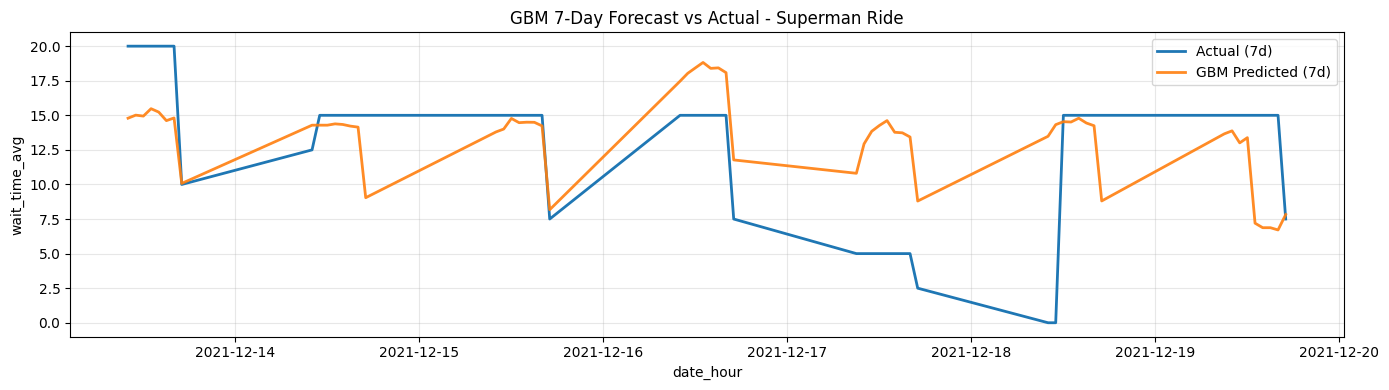

saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\src\models\superman_ride_gradient_boosting.joblib

Attraction: Swing Ride
GBM CV [Swing Ride]: [########################] 100% (48/48)
best params: {'n_estimators': 450, 'learning_rate': 0.03, 'max_depth': 4, 'subsample': 0.8, 'min_samples_leaf': 2}
validation MAE (CV mean): 9.306022193222022
7-day rows: 85
7-day valid eval rows: 85
7-day MAE: 6.8315866886291605
7-day RMSE: 10.307926574378477


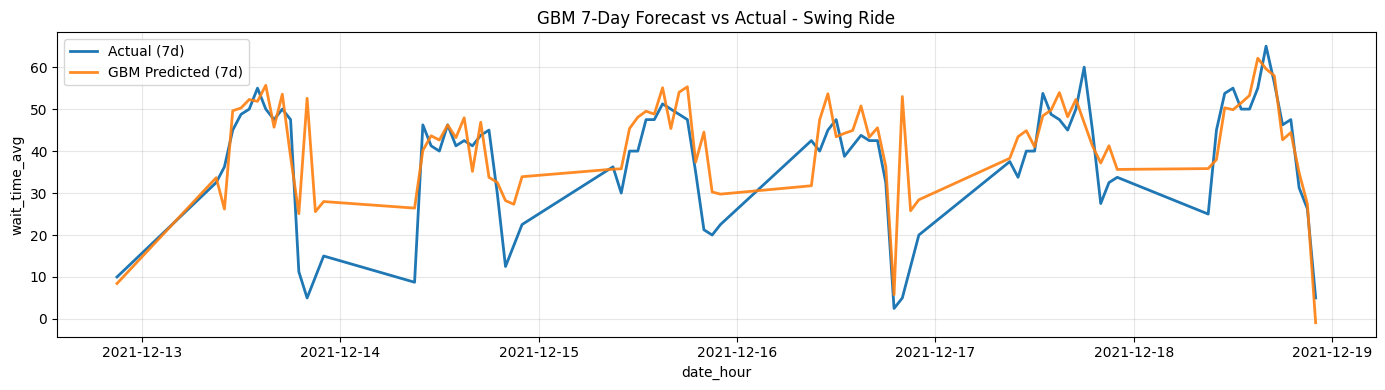

saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\src\models\swing_ride_gradient_boosting.joblib

Attraction: Water Ride
GBM CV [Water Ride]: [########################] 100% (48/48)
best params: {'n_estimators': 350, 'learning_rate': 0.05, 'max_depth': 3, 'subsample': 0.9, 'min_samples_leaf': 2}
validation MAE (CV mean): 5.8528771044758425
7-day rows: 81
7-day valid eval rows: 81
7-day MAE: 5.856235442700353
7-day RMSE: 7.259870814619416


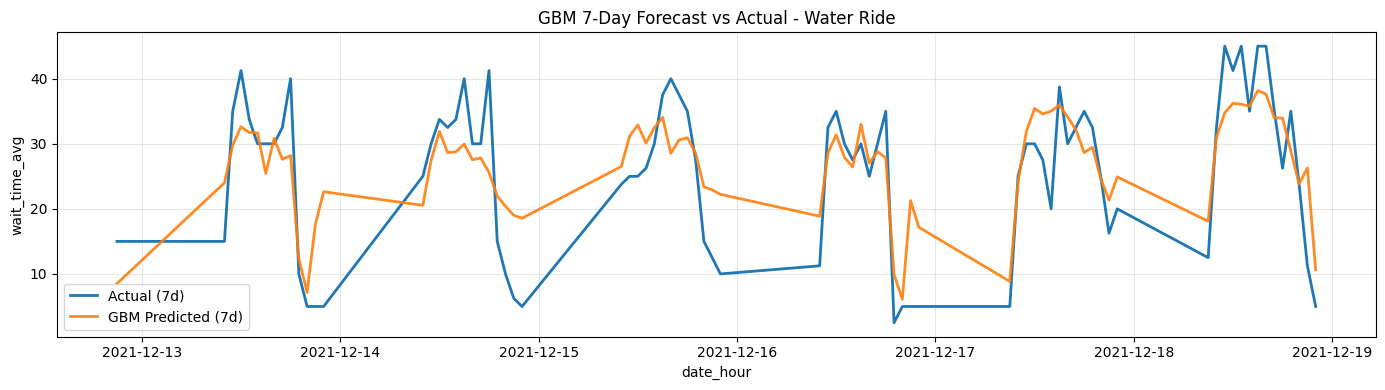

saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\src\models\water_ride_gradient_boosting.joblib

Attraction: Zipline
GBM CV [Zipline]: [########################] 100% (48/48)
best params: {'n_estimators': 450, 'learning_rate': 0.03, 'max_depth': 4, 'subsample': 0.8, 'min_samples_leaf': 2}
validation MAE (CV mean): 6.965584320645429
7-day rows: 97
7-day valid eval rows: 97
7-day MAE: 14.654954874352468
7-day RMSE: 18.52956623199952


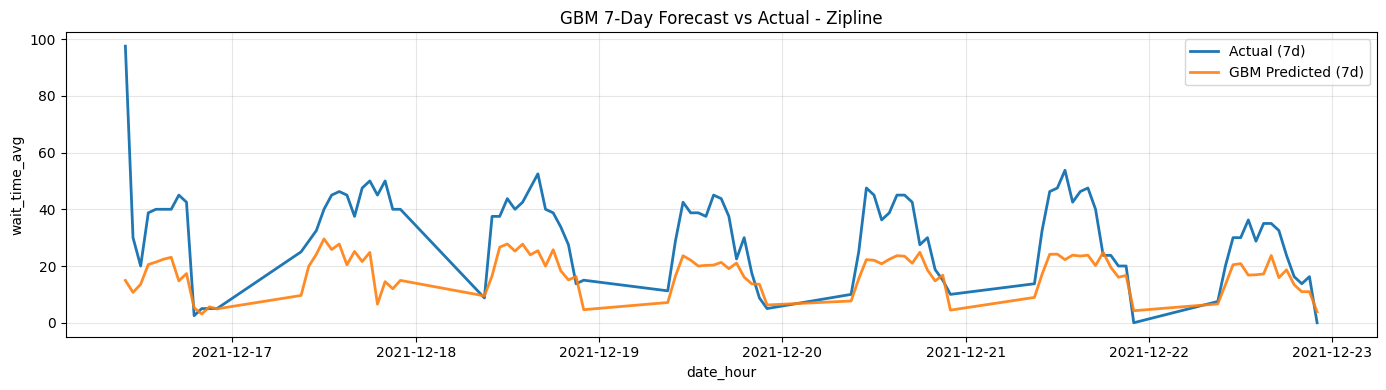

saved model: C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENCE\0 STUDY\M2\Hackathon\code\src\models\zipline_gradient_boosting.joblib

Finished. Saved models: 23


,attraction_name,best_params,validation_mae_cv,mae_7d,rmse_7d,rows_7d,model_path
0,Crazy Dance,"{'n_estimators': 150, 'learning_rate': 0.03, '...",0.500482,0.277203,0.729725,79,C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENC...
1,Circus Train,"{'n_estimators': 150, 'learning_rate': 0.03, '...",0.764797,0.381036,0.842146,62,C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENC...
2,Kiddie Coaster,"{'n_estimators': 200, 'learning_rate': 0.03, '...",2.283397,1.383649,1.860324,62,C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENC...
3,Oz Theatre,"{'n_estimators': 150, 'learning_rate': 0.03, '...",3.792180,3.213274,4.062238,58,C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENC...
4,Bumper Cars,"{'n_estimators': 450, 'learning_rate': 0.03, '...",3.619022,3.678398,4.955853,85,C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENC...
5,Superman Ride,"{'n_estimators': 300, 'learning_rate': 0.03, '...",4.796254,3.940081,5.302719,58,C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENC...
6,Dizzy Dropper,"{'n_estimators': 450, 'learning_rate': 0.03, '...",4.202749,4.324278,5.831799,85,C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENC...
7,Inverted Coaster,"{'n_estimators': 400, 'learning_rate': 0.03, '...",14.012864,4.447609,5.495465,58,C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENC...
8,Haunted House,"{'n_estimators': 450, 'learning_rate': 0.03, '...",5.184746,4.532254,5.786327,83,C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENC...
9,Roller Coaster,"{'n_estimators': 300, 'learning_rate': 0.03, '...",5.769959,5.138716,6.329382,82,C:\Users\artur\Desktop\ESSEC MS IN DATA SCIENC...


In [5]:
results = []
saved_models = {}

for attraction_name in tqdm(attractions):
    print('\n' + '=' * 100)
    print('Attraction:', attraction_name)

    # 1) Train boosting on train data (includes CV-based parameter search).
    trained = gbm_train(
        train_df=train_df,
        attraction_name=attraction_name,
        validation_ratio=0.2,
        cv_splits=5,
        show_progress=True,
    )

    best_params = dict(trained['best_params'])
    feature_cols = list(trained['feature_cols'])
    print('best params:', best_params)
    print('validation MAE (CV mean):', trained['validation_mae'])

    # 2) Evaluate on first 7 calendar days of this attraction's test window.
    test_attr = test_df[test_df['ENTITY_DESCRIPTION_SHORT'].astype(str).eq(attraction_name)].copy()
    test_attr['date_hour'] = pd.to_datetime(test_attr['date_hour'], errors='coerce')
    test_attr = test_attr.sort_values('date_hour').reset_index(drop=True)

    if test_attr.empty:
        print('No test rows for this attraction. Skipping metrics/plot/final save.')
        continue

    start_day = test_attr['date_hour'].dt.floor('D').min()
    end_day_excl = start_day + pd.Timedelta(days=7)

    test_7d = test_attr[(test_attr['date_hour'] >= start_day) & (test_attr['date_hour'] < end_day_excl)].copy()

    if test_7d.empty:
        print('No rows in first 7-day window. Skipping metrics/plot/final save.')
        continue

    y_true = pd.to_numeric(test_7d['wait_time_avg'], errors='coerce').reset_index(drop=True)
    y_pred = gbm_predict(trained, test_7d).reset_index(drop=True)

    mask = y_true.notna() & y_pred.notna()
    if mask.any():
        err = y_true[mask].to_numpy() - y_pred[mask].to_numpy()
        mae_7d = float(np.mean(np.abs(err)))
        rmse_7d = float(np.sqrt(np.mean(err ** 2)))
    else:
        mae_7d = np.nan
        rmse_7d = np.nan

    print('7-day rows:', len(test_7d))
    print('7-day valid eval rows:', int(mask.sum()))
    print('7-day MAE:', mae_7d)
    print('7-day RMSE:', rmse_7d)

    pred_7d_df = pd.DataFrame({
        'date_hour': pd.to_datetime(test_7d['date_hour'], errors='coerce').reset_index(drop=True),
        'y_true': y_true,
        'y_pred': y_pred,
    }).sort_values('date_hour').reset_index(drop=True)

    # 3) Plot y_true vs y_pred for 7 days ahead.
    plt.figure(figsize=(14, 4))
    plt.plot(pred_7d_df['date_hour'], pred_7d_df['y_true'], label='Actual (7d)', linewidth=2)
    plt.plot(pred_7d_df['date_hour'], pred_7d_df['y_pred'], label='GBM Predicted (7d)', linewidth=2, alpha=0.9)
    plt.title(f'GBM 7-Day Forecast vs Actual - {attraction_name}')
    plt.xlabel('date_hour')
    plt.ylabel('wait_time_avg')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 4) Refit final model on full available data (train+test from prepared panel) and save.
    full_attr = full_df[full_df['ENTITY_DESCRIPTION_SHORT'].astype(str).eq(attraction_name)].copy()
    full_attr['date_hour'] = pd.to_datetime(full_attr['date_hour'], errors='coerce')
    full_attr = full_attr.sort_values('date_hour').reset_index(drop=True)

    X_full = build_feature_matrix(full_attr, feature_cols)
    y_full = pd.to_numeric(full_attr['wait_time_avg'], errors='coerce')
    train_mask = y_full.notna()

    final_model = GradientBoostingRegressor(random_state=42, **best_params)
    final_model.fit(X_full.loc[train_mask], y_full.loc[train_mask])

    artifact = {
        'attraction_name': attraction_name,
        'model': final_model,
        'feature_cols': feature_cols,
        'best_params': best_params,
    }

    model_path = MODELS_DIR / f"{sanitize_name(attraction_name)}_gradient_boosting.joblib"
    joblib.dump(artifact, model_path)
    saved_models[attraction_name] = str(model_path)
    print('saved model:', model_path)

    results.append({
        'attraction_name': attraction_name,
        'best_params': best_params,
        'validation_mae_cv': float(trained['validation_mae']),
        'mae_7d': mae_7d,
        'rmse_7d': rmse_7d,
        'rows_7d': int(len(test_7d)),
        'model_path': str(model_path),
    })

results_df = pd.DataFrame(results).sort_values(['mae_7d', 'rmse_7d'], na_position='last').reset_index(drop=True)
print('\nFinished. Saved models:', len(saved_models))
results_df
